Dataset Shape: (250, 15)
   household_id  household_size  daily_food_waste_kg  garden_waste_kg  \
0             1               2                 0.57             1.10   
1             2               7                 1.05             2.65   
2             3               1                 0.83             1.77   
3             4               4                 0.88             0.96   
4             5               8                 0.77             1.21   

   paper_waste_kg  composting_practice_score  distance_to_waste_center_km  \
0            1.21                          7                         2.19   
1            0.91                          1                         6.12   
2            1.24                          8                         8.65   
3            0.19                          9                         5.23   
4            0.37                          3                         1.11   

   waste_collection_frequency_per_week  awareness_score  income_level_ind

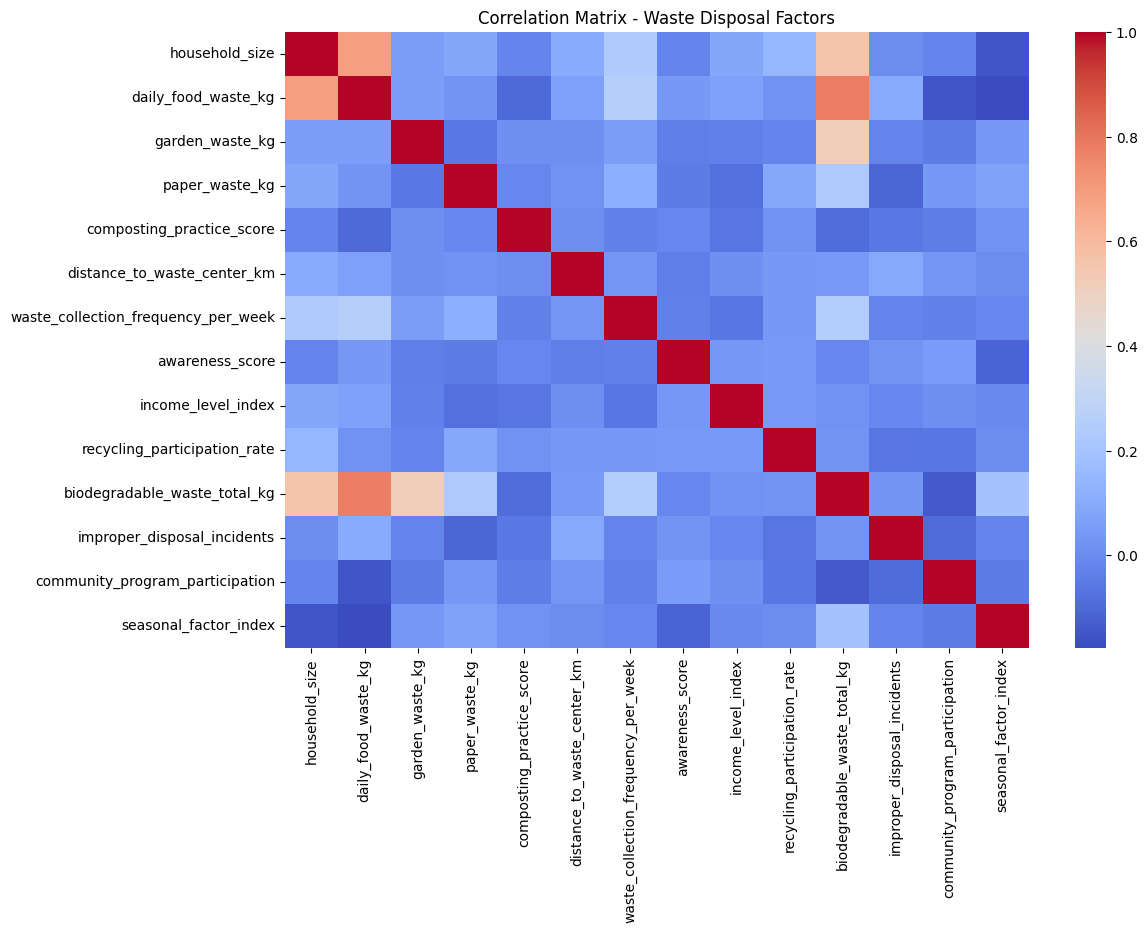

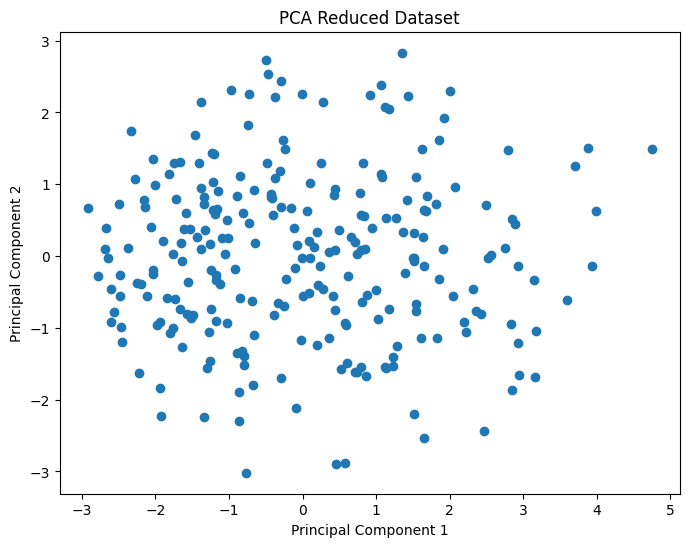


Cluster Distribution:
cluster
1    73
0    65
2    64
3    48
Name: count, dtype: int64


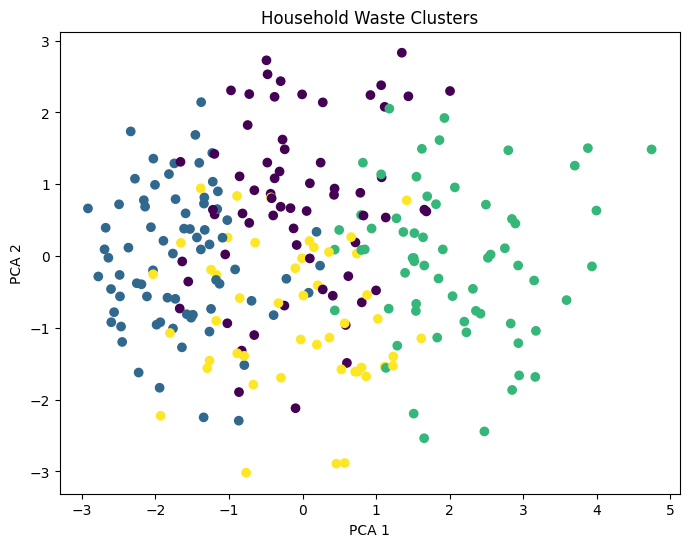


Gradient Boosting RMSE: 0.5023947487312308
Neural Network RMSE: 1.774795572494053

Precision: 1.0
Recall: 0.9473684210526315


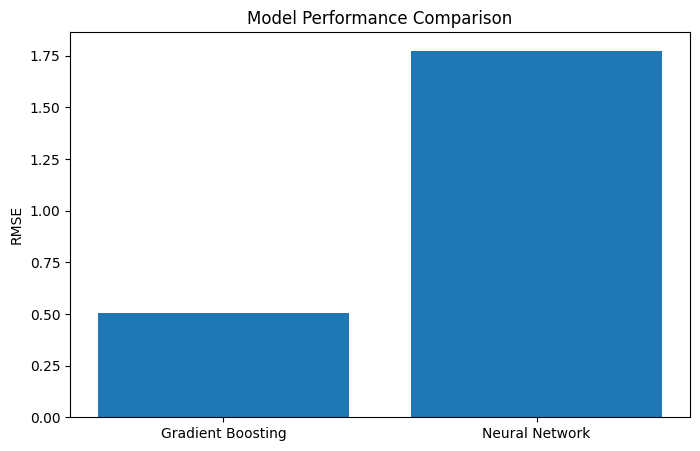


Feature Importance:
                                Feature  Importance
1                   daily_food_waste_kg    0.593891
2                       garden_waste_kg    0.230646
12                seasonal_factor_index    0.096280
3                        paper_waste_kg    0.054859
0                        household_size    0.016653
13                              cluster    0.003760
5           distance_to_waste_center_km    0.001467
10          improper_disposal_incidents    0.000724
9          recycling_participation_rate    0.000465
6   waste_collection_frequency_per_week    0.000440
7                       awareness_score    0.000332
4             composting_practice_score    0.000318
8                    income_level_index    0.000162
11      community_program_participation    0.000001


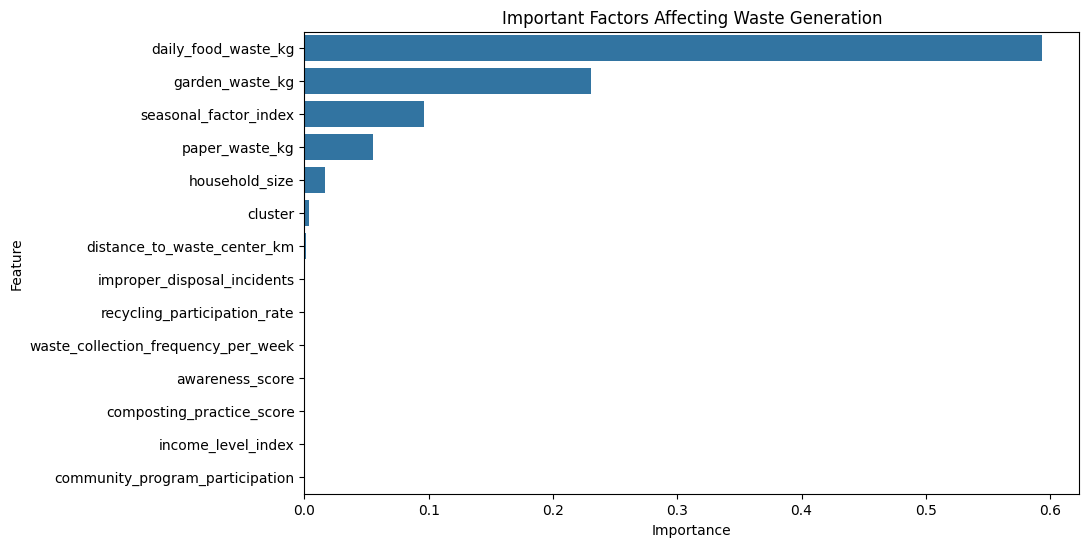


===== MODEL SUMMARY =====
Gradient Boosting RMSE: 0.5023947487312308
Neural Network RMSE: 1.774795572494053
Precision: 1.0
Recall: 0.9473684210526315


In [1]:
# ==========================================================
# Biodegradable Waste Disposal Data Analysis Project
# Supervised + Unsupervised Learning
# Dataset File: Biodegradable_Waste_Disposal_Dataset.xlsx
# ==========================================================

# Install required libraries
!pip install openpyxl seaborn scikit-learn

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, precision_score, recall_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

# ----------------------------------------------------------
# 1 Load Dataset
# ----------------------------------------------------------

file_path = "Biodegradable_Waste_Disposal_Dataset.xlsx"

df = pd.read_excel(file_path)

print("Dataset Shape:", df.shape)
print(df.head())

# ----------------------------------------------------------
# 2 Data Cleaning
# ----------------------------------------------------------

print("\nMissing Values:")
print(df.isnull().sum())

# Fill missing values with column mean
df = df.fillna(df.mean())

# Remove household_id from analysis
df_features = df.drop(columns=["household_id"])

# ----------------------------------------------------------
# 3 Correlation Matrix
# ----------------------------------------------------------

plt.figure(figsize=(12,8))
corr = df_features.corr()

sns.heatmap(corr, cmap="coolwarm", annot=False)

plt.title("Correlation Matrix - Waste Disposal Factors")
plt.show()

# ----------------------------------------------------------
# 4 Feature Scaling
# ----------------------------------------------------------

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_features)

# ----------------------------------------------------------
# 5 PCA Dimensionality Reduction
# ----------------------------------------------------------

pca = PCA(n_components=2)

pca_result = pca.fit_transform(scaled_data)

plt.figure(figsize=(8,6))
plt.scatter(pca_result[:,0], pca_result[:,1])

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Reduced Dataset")
plt.show()

# ----------------------------------------------------------
# 6 Unsupervised Learning: K-Means Clustering
# ----------------------------------------------------------

kmeans = KMeans(n_clusters=4, random_state=42)

clusters = kmeans.fit_predict(scaled_data)

df['cluster'] = clusters

print("\nCluster Distribution:")
print(df['cluster'].value_counts())

# Cluster Visualization

plt.figure(figsize=(8,6))
plt.scatter(pca_result[:,0], pca_result[:,1], c=clusters)

plt.title("Household Waste Clusters")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

# ----------------------------------------------------------
# 7 Supervised Learning Setup
# Target Variable: biodegradable_waste_total_kg
# ----------------------------------------------------------

X = df.drop(columns=["biodegradable_waste_total_kg","household_id"])
y = df["biodegradable_waste_total_kg"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----------------------------------------------------------
# 8 Gradient Boosting Model
# ----------------------------------------------------------

gb_model = GradientBoostingRegressor()

gb_model.fit(X_train, y_train)

gb_predictions = gb_model.predict(X_test)

gb_rmse = np.sqrt(mean_squared_error(y_test, gb_predictions))

print("\nGradient Boosting RMSE:", gb_rmse)

# ----------------------------------------------------------
# 9 Neural Network Model
# ----------------------------------------------------------

nn_model = MLPRegressor(hidden_layer_sizes=(64,32),
                        max_iter=500,
                        random_state=42)

nn_model.fit(X_train, y_train)

nn_predictions = nn_model.predict(X_test)

nn_rmse = np.sqrt(mean_squared_error(y_test, nn_predictions))

print("Neural Network RMSE:", nn_rmse)

# ----------------------------------------------------------
# 10 Precision and Recall
# Convert waste level into binary classification
# ----------------------------------------------------------

threshold = df["biodegradable_waste_total_kg"].mean()

y_test_binary = (y_test > threshold).astype(int)
pred_binary = (gb_predictions > threshold).astype(int)

precision = precision_score(y_test_binary, pred_binary)
recall = recall_score(y_test_binary, pred_binary)

print("\nPrecision:", precision)
print("Recall:", recall)

# ----------------------------------------------------------
# 11 Model Comparison
# ----------------------------------------------------------

models = ["Gradient Boosting","Neural Network"]
scores = [gb_rmse, nn_rmse]

plt.figure(figsize=(8,5))
plt.bar(models, scores)

plt.title("Model Performance Comparison")
plt.ylabel("RMSE")

plt.show()

# ----------------------------------------------------------
# 12 Feature Importance (Important for Project Explanation)
# ----------------------------------------------------------

importance = gb_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
print(feature_importance)

plt.figure(figsize=(10,6))

sns.barplot(x="Importance", y="Feature", data=feature_importance)

plt.title("Important Factors Affecting Waste Generation")

plt.show()

# ----------------------------------------------------------
# 13 Summary
# ----------------------------------------------------------

print("\n===== MODEL SUMMARY =====")
print("Gradient Boosting RMSE:", gb_rmse)
print("Neural Network RMSE:", nn_rmse)
print("Precision:", precision)
print("Recall:", recall)


# New Section